# Ejercicio 1

Construya una red de Kohonen de 2 entradas que aprenda una distribución uniforme dentro del círculo unitario. Mostrar el mapa de preservación de topología. Probar con distribuciones uniformes dentro de otras figuras geométricas.

In [169]:
import numpy as np
import matplotlib.pyplot as plt

In [170]:
np.random.seed(110007)

In [171]:
def visualize_dataset(dataset, existing_plot=False):
    if not existing_plot:
        plt.figure(figsize=(3, 3))
        
    plt.scatter(dataset[:, 0], dataset[:, 1], alpha=0.2, label='Dataset')

    if not existing_plot:
        plt.grid()
        plt.tight_layout()
        plt.show()

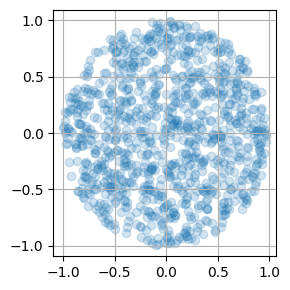

In [172]:
n_samples = 1000

theta = np.random.uniform(low=0, high=2*np.pi, size=n_samples)
r = np.sqrt(np.random.uniform(low=0, high=1, size=n_samples))
data_circle = np.c_[r * np.cos(theta), r * np.sin(theta)]

visualize_dataset(data_circle)

In [173]:
class KohonenNet:
    def __init__(self, n_neurons=(10, 10), name=None):
        self.weights = np.random.uniform(low=-1.0, high=1.0, size=(n_neurons[0], n_neurons[1], 2))
        self.n_neurons = n_neurons
        self.grid_x, self.grid_y = np.meshgrid(np.arange(n_neurons[0]), np.arange(n_neurons[1]), indexing='ij')
        self.name = name

    def train(self, X, epochs=100, lr=0.01, sigma_sq_start=1.0, plot_epochs=None):
        n_samples = X.shape[0]
        
        for epoch in range(epochs):
            idx = np.random.permutation(n_samples)
            sigma_sq = sigma_sq_start * (1 - epoch / epochs)

            if epoch + 1 in plot_epochs:
                self.visualize(X, epoch + 1)

            for i in idx:
                x = X[i]
                dist_sq = np.sum((self.weights - x) ** 2, axis=2)
                i_star = np.unravel_index(np.argmin(dist_sq), dist_sq.shape)
                dist_sq_grid = (self.grid_x - i_star[0])**2 + (self.grid_y - i_star[1])**2
                neighbourhood = np.exp(-dist_sq_grid / (2 * sigma_sq))
                delta_weights = lr * neighbourhood[:, :, np.newaxis] * (x - self.weights)
                self.weights += delta_weights

    def visualize(self, dataset, epoch):
        plt.figure(figsize=(4, 4))
        
        visualize_dataset(dataset, existing_plot=True)
        
        weights = self.weights.reshape(-1, 2)
        
        for i in range(self.n_neurons[0]):
            for j in range(self.n_neurons[1] - 1):
                plt.plot([self.weights[i, j, 0], self.weights[i, j+1, 0]], 
                         [self.weights[i, j, 1], self.weights[i, j+1, 1]], 'r-', alpha=0.5)
        
        for i in range(model.n_neurons[0] - 1):
            for j in range(model.n_neurons[1]):
                plt.plot([self.weights[i, j, 0], self.weights[i+1, j, 0]], 
                         [self.weights[i, j, 1], self.weights[i+1, j, 1]], 'r-', alpha=0.5)
        
        plt.scatter(weights[:, 0], weights[:, 1], c='tab:red', s=100, edgecolors='black', label='Neuronas')
    
        plt.xlabel('$x_1$')
        plt.ylabel('$x_2$')
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.savefig(f'../informe/img/ej1/{model.name}_{epoch}.svg')
        plt.show()

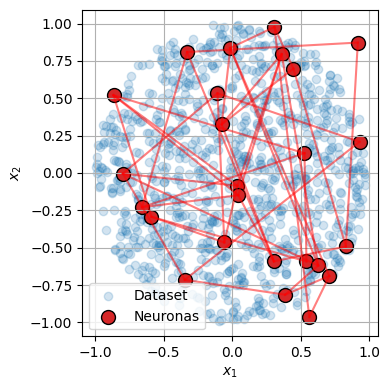

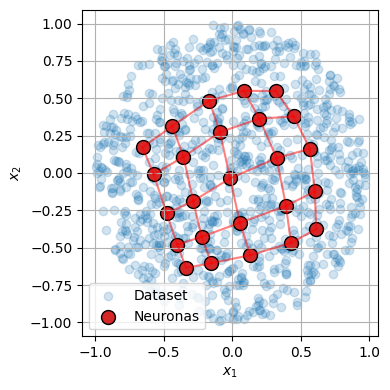

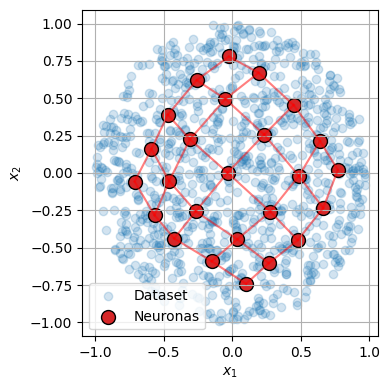

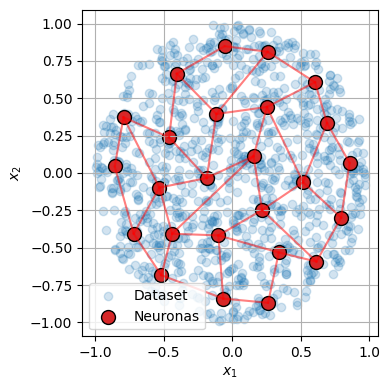

In [174]:
model = KohonenNet(n_neurons=(5, 5), name='circle')
model.train(data_circle, sigma_sq_start=1.0, lr=0.1, epochs=800, plot_epochs=[1, 2, 300, 800])

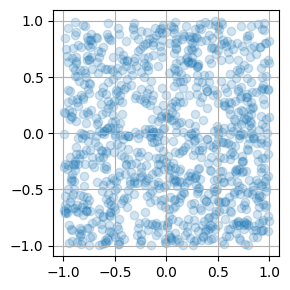

In [175]:
data_square = np.random.uniform(low=-1, high=1, size=(n_samples, 2))

visualize_dataset(data_square)

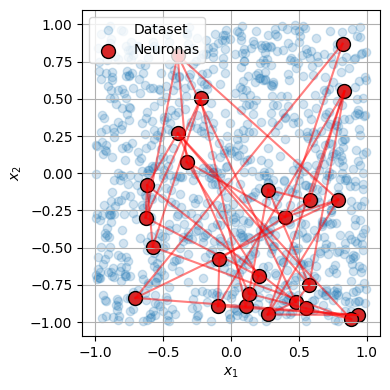

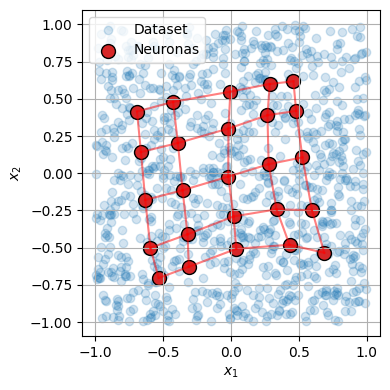

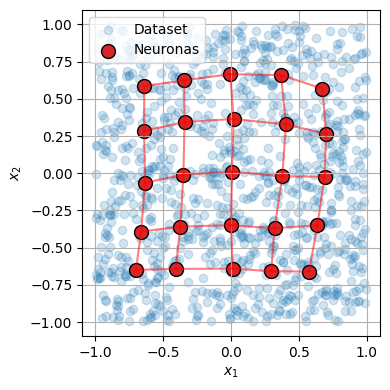

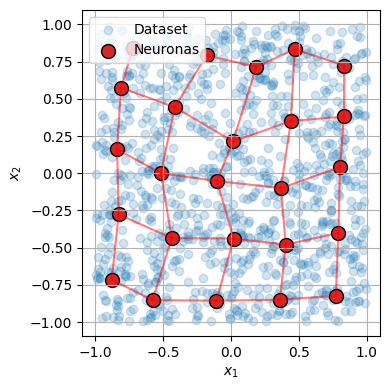

In [176]:
model = KohonenNet(n_neurons=(5, 5), name='square')
model.train(data_square, sigma_sq_start=1.0, lr=0.1, epochs=800, plot_epochs=[1, 2, 300, 800])

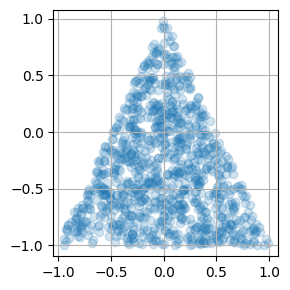

In [177]:
u = np.random.uniform(0, 1, n_samples)
v = np.random.uniform(-1, 1, n_samples)
y = 1 - 2 * np.sqrt(u)
x = v * (1 - y) / 2
data_triangle = np.column_stack((x, y))

visualize_dataset(data_triangle)  

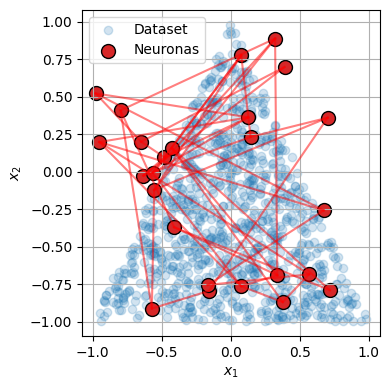

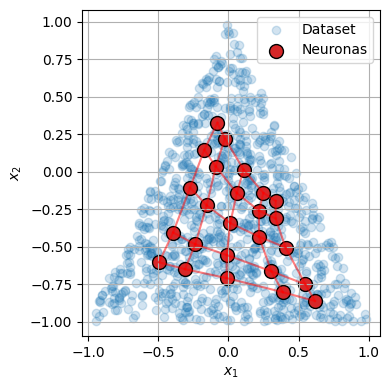

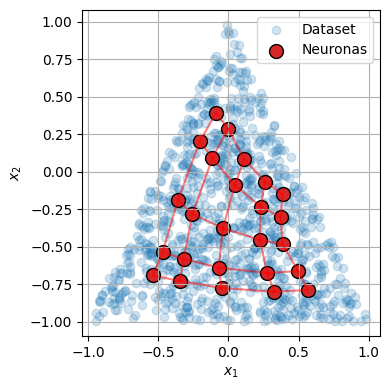

In [ ]:
model = KohonenNet(n_neurons=(5, 5), name='triangle')
model.train(data_triangle, sigma_sq_start=1.0, lr=0.1, epochs=800, plot_epochs=[1, 2, 300, 800])